# Heart Disease (UCI): Data Quality Assessment & Preprocessing 



## Import Required Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)


## 1. Load Dataset

In [9]:
df = pd.read_csv("heart_disease_uci.csv")
df.head(10)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
5,6,56,Male,Cleveland,atypical angina,120.0,236.0,False,normal,178.0,False,0.8,upsloping,0.0,normal,0
6,7,62,Female,Cleveland,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6,downsloping,2.0,normal,3
7,8,57,Female,Cleveland,asymptomatic,120.0,354.0,False,normal,163.0,True,0.6,upsloping,0.0,normal,0
8,9,63,Male,Cleveland,asymptomatic,130.0,254.0,False,lv hypertrophy,147.0,False,1.4,flat,1.0,reversable defect,2
9,10,53,Male,Cleveland,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1,downsloping,0.0,reversable defect,1


## 2. Data Quality Assessment

### 2.1 Check Data Types
Data types must match the real meaning of each column.

Common issues in the Heart Disease UCI dataset:
- Missing values encoded as `?`
- Numeric columns loaded as `object` because of `?`


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


### 2.2 Convert Incorrect Data Types

We will:
- Replace `?` with `NaN`
- Convert expected numeric columns to numeric (coerce errors to `NaN`)


In [11]:
# Replace common non-standard missing markers with NaN
df_clean = df.replace({"?": np.nan, "NA": np.nan, "N/A": np.nan, "": np.nan}).copy()

# Convert likely numeric columns (safe if column not present)
likely_numeric = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

for col in likely_numeric:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean.dtypes


id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

## 3. Handling Missing Values

### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.


In [12]:
missing_counts = df_clean.isna().sum().sort_values(ascending=False)
missing_counts[missing_counts > 0]


ca          611
thal        486
slope       309
fbs          90
oldpeak      62
trestbps     59
thalch       55
exang        55
chol         30
restecg       2
dtype: int64

### 3.2 Demonstration: Introduce Artificial Missing Values


In [13]:
df_missing = df_clean.copy()

# If there are no missing values, introduce a small number for demonstration
if df_missing.isna().sum().sum() == 0:
    demo_col = next((c for c in ["chol", "trestbps", "thalach", "oldpeak", "age"] if c in df_missing.columns), None)
    if demo_col is None:
        raise ValueError("No suitable numeric column found to demonstrate missing values.")

    # Introduce NaNs in first 6 rows of a numeric column
    df_missing.loc[0:5, demo_col] = np.nan
    print(f"Introduced artificial missing values in column: {demo_col}")

df_missing.isna().sum()[df_missing.isna().sum() > 0]


trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
dtype: int64

### Strategy 1: Remove Records


In [14]:
df_removed = df_missing.dropna()
df_missing.shape, df_removed.shape


((920, 16), (299, 16))

### Strategy 2: Mean Imputation


In [20]:
df_imputed_mean = df_missing.copy()

num_cols = df_imputed_mean.select_dtypes(include=[np.number]).columns.tolist()
if "num" in num_cols:
    num_cols.remove("num")

for col in num_cols:
    df_imputed_mean[col] = df_imputed_mean[col].fillna(df_imputed_mean[col].mean())
df_imputed_mean.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


### Strategy 3: Median Imputation
The median is more robust to outliers than the mean.
It is preferred for skewed data.


In [21]:
df_imputed_median = df_missing.copy()

num_cols = df_imputed_median.select_dtypes(include=[np.number]).columns.tolist()
if "num" in num_cols:
    num_cols.remove("num")

for col in num_cols:
    df_imputed_median[col] = df_imputed_median[col].fillna(df_imputed_median[col].median())

df_imputed_median.isna().sum()[df_imputed_median.isna().sum() > 0]


fbs         90
restecg      2
exang       55
slope      309
thal       486
dtype: int64

✅ For the rest of the notebook, we will proceed with **Median Imputation**.

In [22]:
df_final = df_imputed_median.copy()
df_final.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using IQR method.


### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**



In [23]:
numeric_features = df_final.select_dtypes(include=[np.number]).columns.tolist()
if "num" in numeric_features:
    numeric_features.remove("num")

def iqr_bounds(series: pd.Series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

outlier_report = []
for col in numeric_features:
    lower, upper = iqr_bounds(df_final[col])
    outliers = ((df_final[col] < lower) | (df_final[col] > upper)).sum()
    outlier_report.append((col, int(outliers), float(lower), float(upper)))

outlier_df = pd.DataFrame(outlier_report, columns=["feature", "outlier_count", "lower_bound", "upper_bound"])
outlier_df.sort_values("outlier_count", ascending=False).head(10)


,feature,outlier_count,lower_bound,upper_bound
3,chol,185,43.875,400.875
6,ca,128,0.000,0.000
2,trestbps,28,90.000,170.000
5,oldpeak,16,-2.250,3.750
4,thalch,2,66.000,210.000
0,id,0,-458.500,1379.500
1,age,0,27.500,79.500


### Remove Outliers (Optional)


In [24]:
df_no_outliers = df_final.copy()

mask = pd.Series(True, index=df_no_outliers.index)
for col in numeric_features:
    lower, upper = iqr_bounds(df_no_outliers[col])
    mask &= df_no_outliers[col].between(lower, upper)

df_no_outliers = df_no_outliers[mask]
df_final.shape, df_no_outliers.shape


((920, 16), (590, 16))

### Capping Outliers (Percentile/IQR Capping)



In [25]:
df_capped = df_final.copy()

for col in numeric_features:
    lower, upper = iqr_bounds(df_capped[col])
    df_capped[col] = df_capped[col].clip(lower, upper)

df_capped.describe().T.loc[numeric_features, ["min", "max", "mean", "std"]].head(10)


,min,max,mean,std
id,1.000,920.000,460.500000,265.725422
age,28.000,77.000,53.510870,9.424685
trestbps,90.000,170.000,131.725000,16.921872
chol,43.875,400.875,207.095516,91.530131
thalch,66.000,202.000,137.702174,25.116321
oldpeak,-2.250,3.750,0.843696,1.022640
ca,0.000,0.000,0.000000,0.000000


## 5. Data Transformation – Normalization


### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually 0–1.


In [26]:
minmax_scaler = MinMaxScaler()

df_minmax = df_capped.copy()
df_minmax[numeric_features] = minmax_scaler.fit_transform(df_minmax[numeric_features])

df_minmax.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,0.000000,0.714286,Male,Cleveland,typical angina,0.6875,0.529762,True,lv hypertrophy,0.617647,False,0.758333,downsloping,0.0,fixed defect,0
1,0.001088,0.795918,Male,Cleveland,asymptomatic,0.8750,0.678221,False,lv hypertrophy,0.308824,True,0.625000,flat,0.0,normal,2
2,0.002176,0.795918,Male,Cleveland,asymptomatic,0.3750,0.518557,False,lv hypertrophy,0.463235,True,0.808333,flat,0.0,reversable defect,1
3,0.003264,0.183673,Male,Cleveland,non-anginal,0.5000,0.577381,False,normal,0.889706,False,0.958333,downsloping,0.0,normal,0
4,0.004353,0.265306,Female,Cleveland,atypical angina,0.5000,0.448529,False,lv hypertrophy,0.779412,False,0.608333,upsloping,0.0,normal,0


### Z-Score Normalization
Z-score standardization transforms the data so that:
- Mean becomes 0
- Standard deviation becomes 1


In [27]:
z_scaler = StandardScaler()

df_zscore = df_capped.copy()
df_zscore[numeric_features] = z_scaler.fit_transform(df_zscore[numeric_features])

df_zscore.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,-1.730169,1.007386,Male,Cleveland,typical angina,0.784914,0.283170,True,lv hypertrophy,0.489901,False,1.424838,downsloping,0.0,fixed defect,0
1,-1.726404,1.432034,Male,Cleveland,asymptomatic,1.671823,0.862529,False,lv hypertrophy,-1.183228,True,0.642124,flat,0.0,normal,2
2,-1.722639,1.432034,Male,Cleveland,asymptomatic,-0.693267,0.239445,False,lv hypertrophy,-0.346663,True,1.718356,flat,0.0,reversable defect,1
3,-1.718873,-1.752828,Male,Cleveland,non-anginal,-0.101995,0.469002,False,normal,1.963848,False,2.598910,downsloping,0.0,normal,0
4,-1.715108,-1.328180,Female,Cleveland,atypical angina,-0.101995,-0.033838,False,lv hypertrophy,1.366302,False,0.544284,upsloping,0.0,normal,0


## Check Correlation Before Applying PCA

We check whether numerical features are correlated.  
If features are strongly correlated, they contain overlapping information.


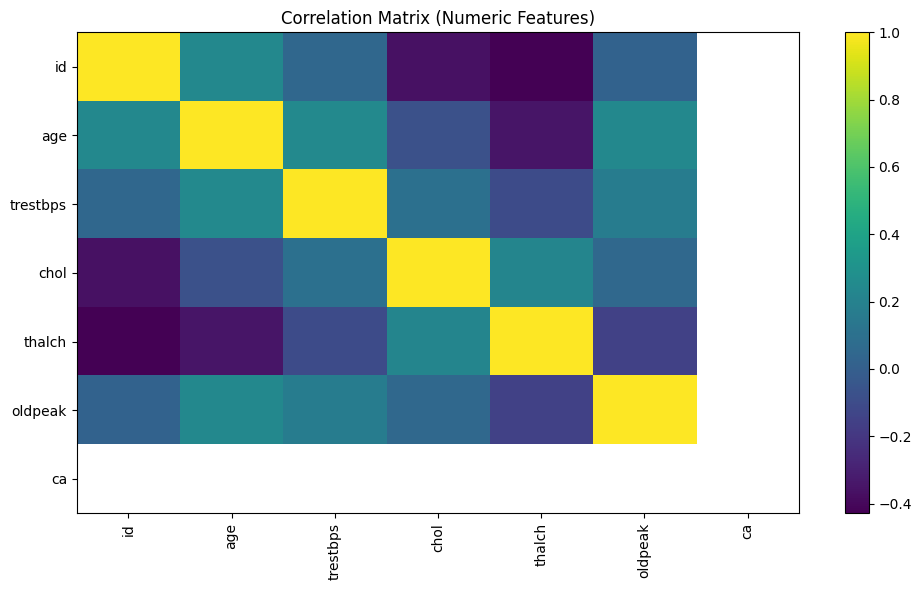

In [28]:
corr = df_capped[numeric_features].corr()

plt.figure(figsize=(10, 6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(numeric_features)), numeric_features, rotation=90)
plt.yticks(range(len(numeric_features)), numeric_features)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.show()


## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.


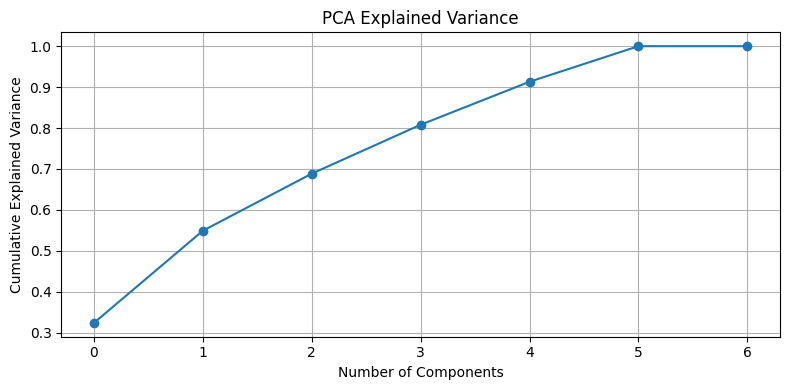

array([0.32406214, 0.22509045, 0.13943003, 0.11953173, 0.10496486,
       0.0869208 , 0.        ])

In [29]:
X_pca_input = df_zscore[numeric_features].copy()

pca = PCA()
X_pca = pca.fit_transform(X_pca_input)

explained = pca.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(explained), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.tight_layout()
plt.show()

explained[:10]


### Choose Components (Example: 95% variance)
We select the smallest number of components that explains at least **95%** variance.


In [30]:
cum_explained = np.cumsum(explained)
k = int(np.argmax(cum_explained >= 0.95) + 1)
print("Components to reach >=95% variance:", k)
print("Cumulative explained variance:", float(cum_explained[k-1]))


Components to reach >=95% variance: 6
Cumulative explained variance: 1.0


## 7. Final Output for Modeling (Ready Dataset)

We will create a clean dataset that you can use for ML:
- Median-imputed
- Outlier-capped
- Standardized numeric features (Z-score)
- Target column `num` kept


In [31]:
df_ready = df_zscore.copy()

# Basic sanity checks
print("Shape:", df_ready.shape)
print("Total missing values:", int(df_ready.isna().sum().sum()))

df_ready.head()


Shape: (920, 16)
Total missing values: 942


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,-1.730169,1.007386,Male,Cleveland,typical angina,0.784914,0.283170,True,lv hypertrophy,0.489901,False,1.424838,downsloping,0.0,fixed defect,0
1,-1.726404,1.432034,Male,Cleveland,asymptomatic,1.671823,0.862529,False,lv hypertrophy,-1.183228,True,0.642124,flat,0.0,normal,2
2,-1.722639,1.432034,Male,Cleveland,asymptomatic,-0.693267,0.239445,False,lv hypertrophy,-0.346663,True,1.718356,flat,0.0,reversable defect,1
3,-1.718873,-1.752828,Male,Cleveland,non-anginal,-0.101995,0.469002,False,normal,1.963848,False,2.598910,downsloping,0.0,normal,0
4,-1.715108,-1.328180,Female,Cleveland,atypical angina,-0.101995,-0.033838,False,lv hypertrophy,1.366302,False,0.544284,upsloping,0.0,normal,0


### Example: Train/Test Split (Optional)

This is **optional** and shown here because it is commonly needed for ML training.


In [32]:
if "num" not in df_ready.columns:
    raise ValueError("Target column 'num' not found. Update the target column name if needed.")

X = df_ready.drop(columns=["num"])
y = df_ready["num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() > 1 else None
)

X_train.shape, X_test.shape


((736, 15), (184, 15))


Tasks done for this LAB
:
- **Task 1**: Identify data quality issues in the dataset.
- **Task 2**: Apply one missing value strategy and explain why.
- **Task 3**: Detect and handle outliers using IQR.
- **Task 4**: Normalize numerical features using both Min-Max and Z-score.
- **Task 5 (Optional)**: Apply PCA and choose components based on explained variance.

